# Detecting batch effects (Python port)

This notebook is a Python port of the `detect_batch_effects.Rmd`
vignette from [biosurf/cyCombine](https://github.com/biosurf/cyCombine).
It demonstrates the two batch-effect diagnostics available in
`pycombine`:

- **`detect_batch_effect_express`** — a fast 3-plot summary: a mean-EMD
  heatmap across markers, per-marker density curves colored by batch,
  and an MDS plot of per-sample medians.
- **`detect_batch_effect`** — the above, plus a UMAP of the uncorrected
  data and a per-marker MAD bar chart.

Run these *before* you decide to correct: if your data already mixes
cleanly across batches, cyCombine correction may do more harm than
good.

## Cofactor guidance

The arcsinh transform compresses the dynamic range of cytometry
intensities. Use the cofactor that matches your instrument:

| Technology        | Cofactor |
| ----------------- | -------- |
| Mass cytometry    | 5        |
| Conventional flow | 150      |
| Full-spectrum flow| 6000     |

## Setup

In [1]:
import os
import tempfile
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scanpy as sc

import pycombine as pc

warnings.filterwarnings('ignore')
sc.set_figure_params(figsize=(4, 4), dpi=80)
print('pycombine', pc.__version__)

pycombine 0.1.0.dev0


## Load the Nuñez PBMC dataset

We reuse the two figshare-hosted FCS files from the
{doc}`cycombine` tutorial. The loader below tries the canonical
download first, falls back to pre-staged files in
`$PYCOMBINE_DATA_DIR`, and finally synthesizes a two-batch AnnData so
the notebook executes even in offline environments.

In [2]:
def _drop_noninformative(a: ad.AnnData) -> ad.AnnData:
    keep = [
        v for v in a.var_names
        if v not in ('Time', 'LD') and '-' not in v
    ]
    return a[:, keep].copy()


def _synthetic_two_batch(n_per_batch: int = 3000, seed: int = 0) -> ad.AnnData:
    local_rng = np.random.default_rng(seed)
    markers = [
        'CD3', 'CD4', 'CD8', 'CD19', 'CD14', 'CD16', 'CD56',
        'CD11c', 'HLADR', 'CD45', 'CD25', 'CD127', 'CD38',
        'CD27', 'CD69',
    ]
    n_markers = len(markers)
    n_types = 6
    type_means = local_rng.normal(1.0, 0.9, (n_types, n_markers)).clip(0, None)

    def _one_batch(shift: float) -> np.ndarray:
        per_type = n_per_batch // n_types
        blocks = []
        for mu in type_means:
            blocks.append(local_rng.normal(mu + shift, 0.35, (per_type, n_markers)))
        return np.clip(np.vstack(blocks), 0, None) * 20

    X1 = _one_batch(0.0)
    X2 = _one_batch(0.8)
    X = np.vstack([X1, X2])
    obs = pd.DataFrame({
        'batch': ['batch1'] * len(X1) + ['batch2'] * len(X2),
        'sample': ['b1_s1'] * len(X1) + ['b2_s1'] * len(X2),
    })
    obs.index = obs.index.astype(str)
    a = ad.AnnData(X=X.astype(float), obs=obs)
    a.var_names = markers
    return a


def load_pbmc_two_batches() -> tuple[ad.AnnData, str]:
    # ---- Canonical figshare download ---------------------------------
    temp_dir_obj = tempfile.TemporaryDirectory()
    data_dir = temp_dir_obj.name
    urls = [
        'https://figshare.com/ndownloader/files/55982654',
        'https://figshare.com/ndownloader/files/55982657',
    ]
    downloaded: list[str] = []
    try:
        for url in urls:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            cd = r.headers.get('Content-Disposition', '')
            name = (
                cd.split('filename=')[1].strip('"\'')
                if 'filename=' in cd
                else os.path.basename(url) + '.fcs'
            )
            path = os.path.join(data_dir, name)
            with open(path, 'wb') as f:
                f.write(r.content)
            downloaded.append(path)
        source = 'figshare'
    except Exception as exc:
        downloaded = []
        source = f'synthetic (download failed: {type(exc).__name__})'
        staged = os.environ.get('PYCOMBINE_DATA_DIR')
        if staged and os.path.isdir(staged):
            found = sorted(
                os.path.join(staged, f)
                for f in os.listdir(staged)
                if f.lower().endswith('.fcs')
            )
            if len(found) >= 2:
                downloaded = found[:2]
                source = f'pre-staged ({staged})'

    if downloaded:
        import readfcs
        adatas = []
        for i, path in enumerate(downloaded, start=1):
            a = readfcs.read(path)
            a = _drop_noninformative(a)
            a.obs['batch'] = f'batch{i}'
            a.obs['sample'] = f'b{i}_s1'
            adatas.append(a)
        adata = ad.concat(adatas, join='outer', index_unique='-')
        # Keep a handle on the temp dir for this session.
        adata.uns['_temp_dir_obj_ref'] = id(temp_dir_obj)
    else:
        adata = _synthetic_two_batch(n_per_batch=3000, seed=0)

    adata.obs['batch'] = adata.obs['batch'].astype('category')
    adata.obs['sample'] = adata.obs['sample'].astype('category')
    adata.obs_names_make_unique()
    return adata, source


adata, data_source = load_pbmc_two_batches()
print('data source:', data_source)
adata

data source: synthetic (download failed: ProxyError)


AnnData object with n_obs × n_vars = 6000 × 15
    obs: 'batch', 'sample'

In [3]:
# Arcsinh-transform before diagnostics. cyCombine recommends cofactor 5
# for CyTOF; change to 150 (flow) or 6000 (spectral) as appropriate.
pc.transform_asinh(adata, cofactor=5, derand=True, seed=0)
adata

AnnData object with n_obs × n_vars = 6000 × 15
    obs: 'batch', 'sample'

## `detect_batch_effect_express` — the quick summary

Call `detect_batch_effect_express` to get a fast three-panel
visualization of batch imbalance:

- an **EMD heatmap** of mean Earth Mover's Distance per marker across
  all batch pairs,
- per-marker **density curves** colored by batch,
- and an **MDS plot** of per-sample medians (requires `sample_key`).

Pass `out_dir=...` to save all three as PNGs; otherwise the function
returns a dict of matplotlib figures you can display inline.

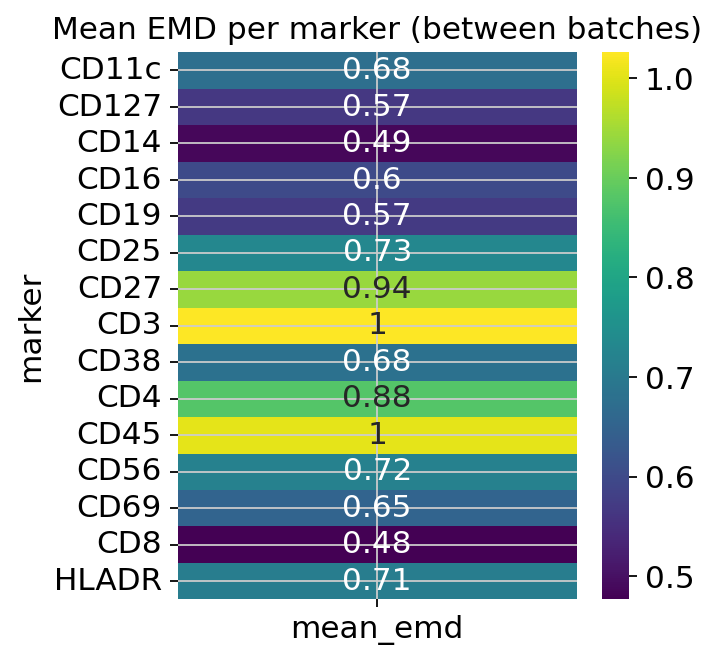

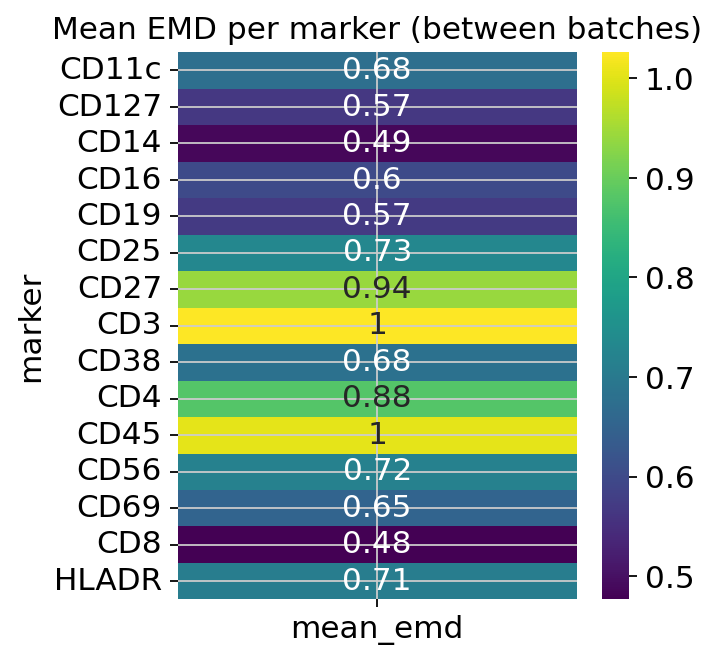

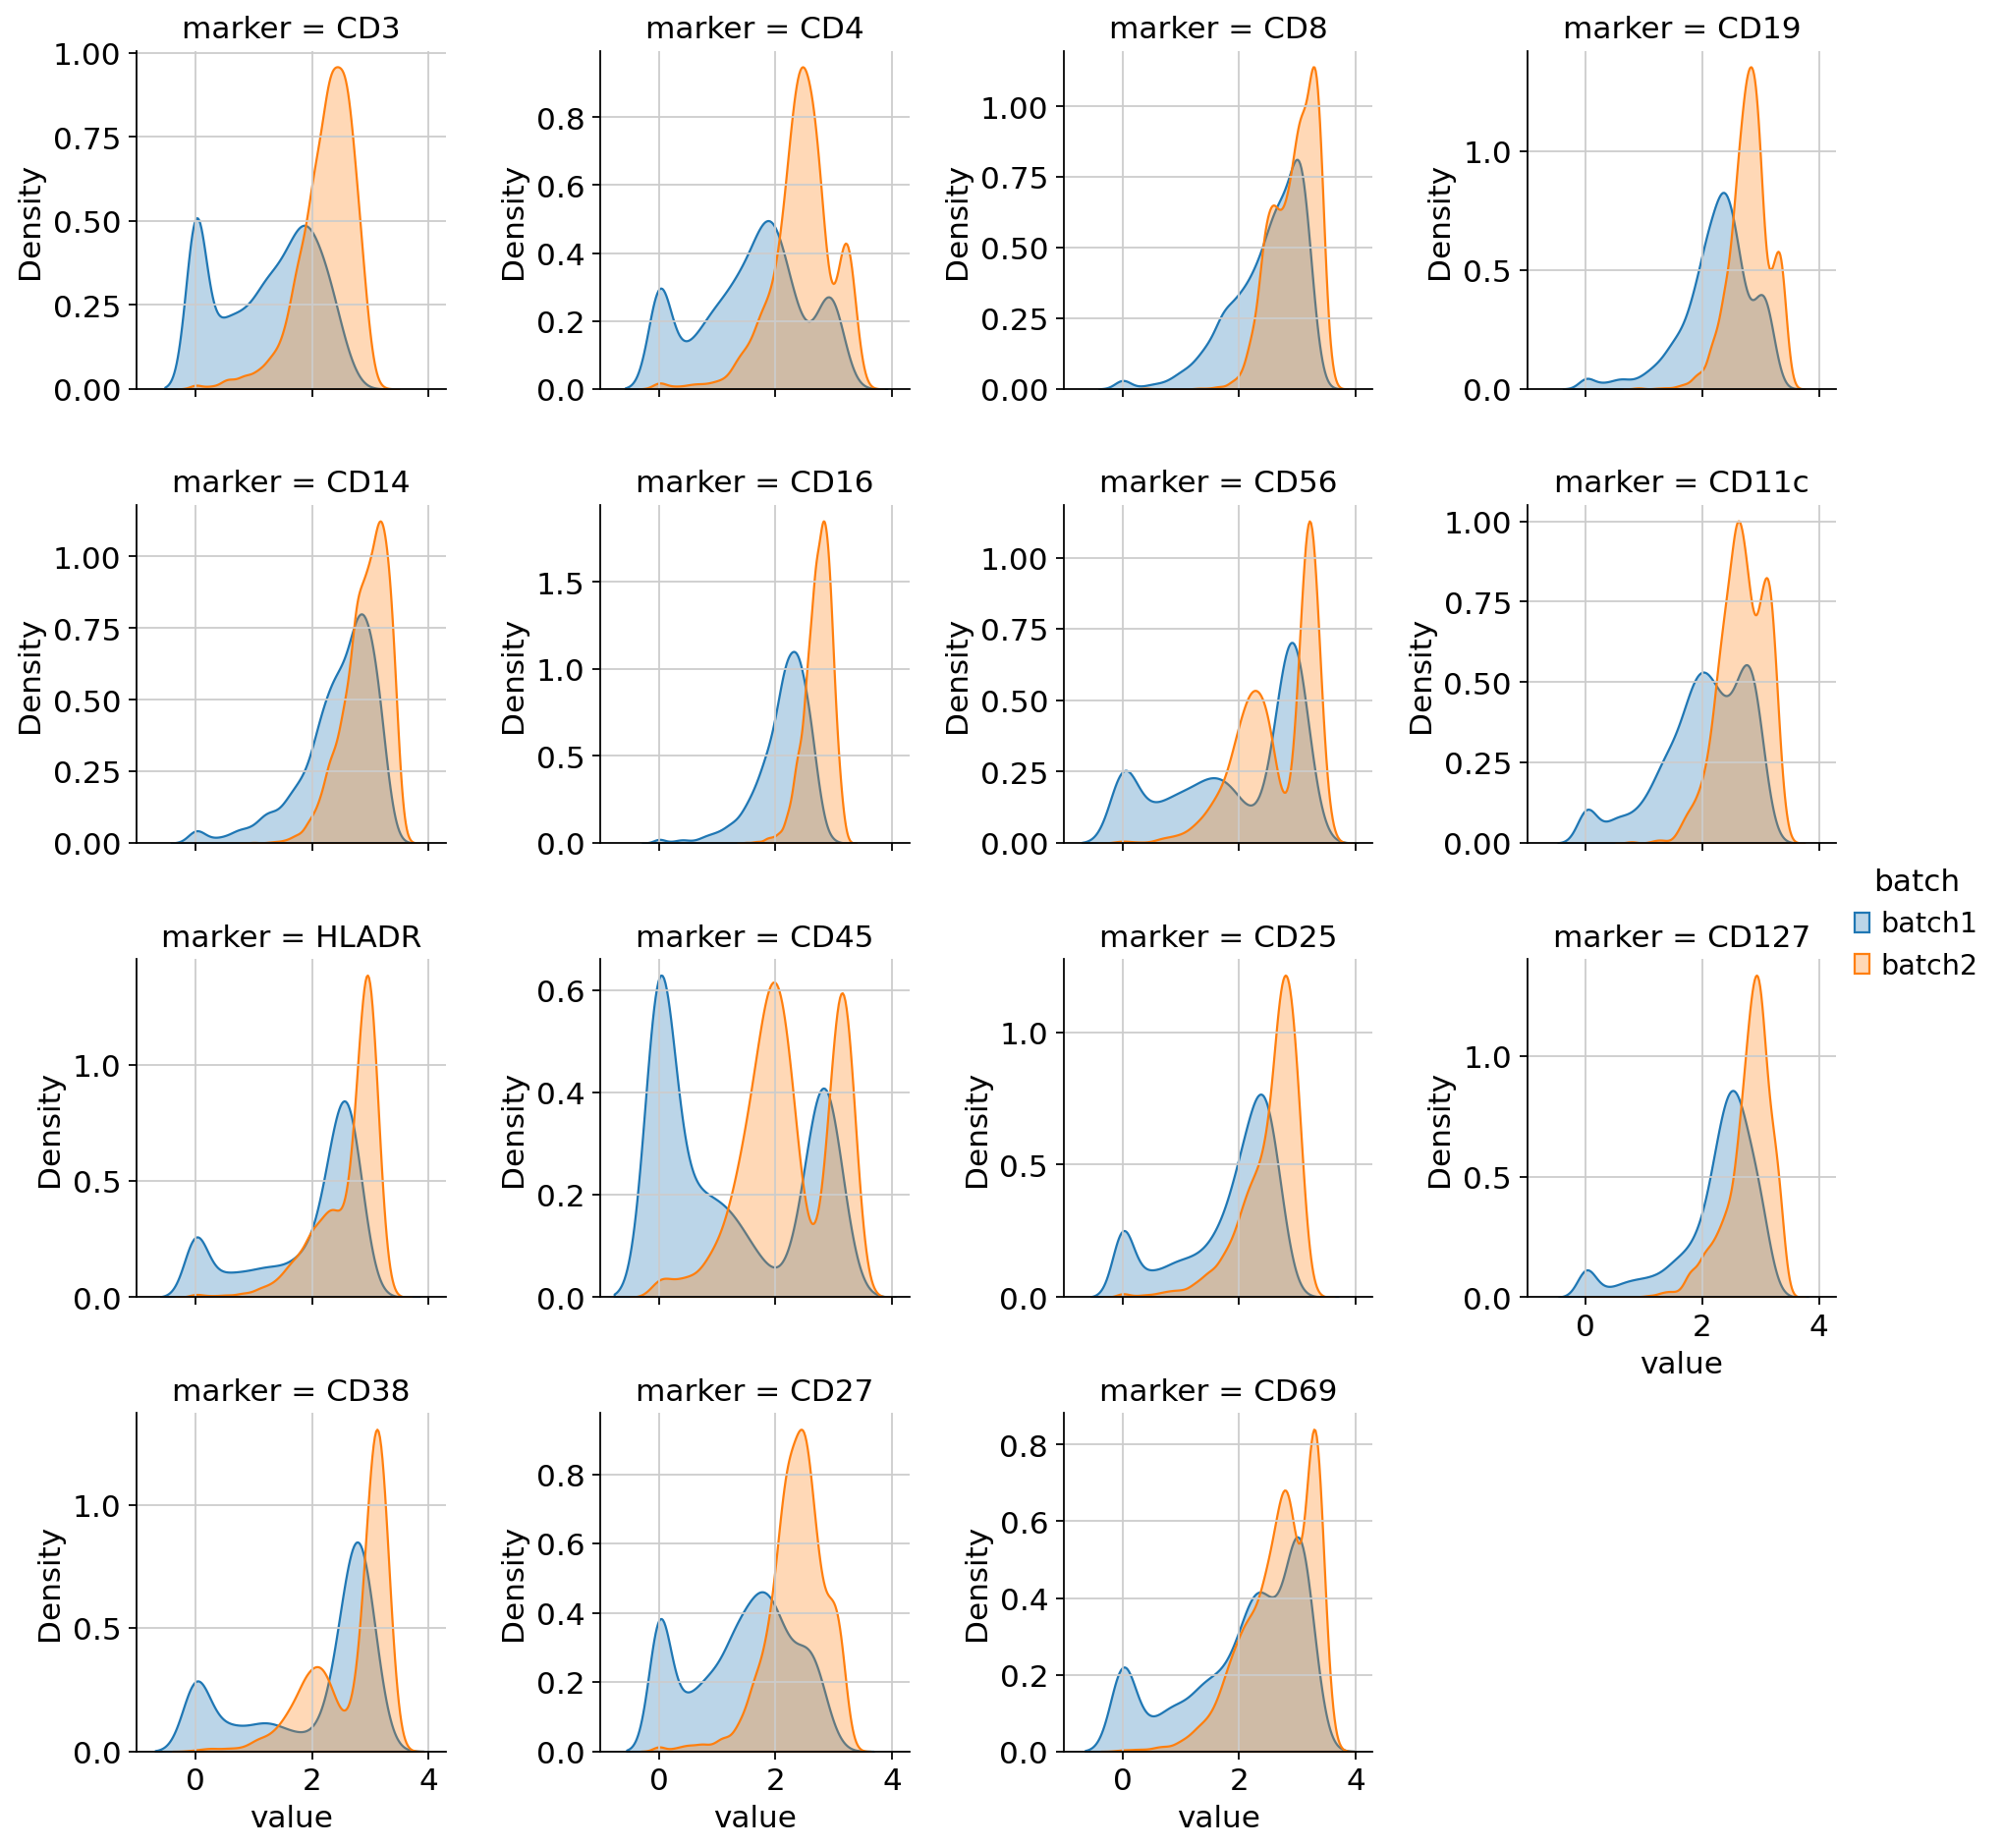

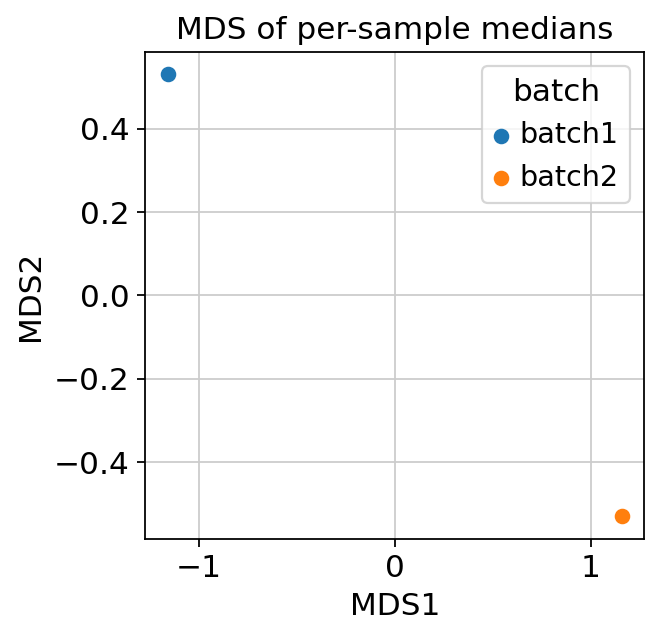

In [4]:
figs_express = pc.detect_batch_effect_express(
    adata,
    batch_key='batch',
    sample_key='sample',
    downsample=5000,
    out_dir=None,
    seed=472,
)
figs_express['emd']

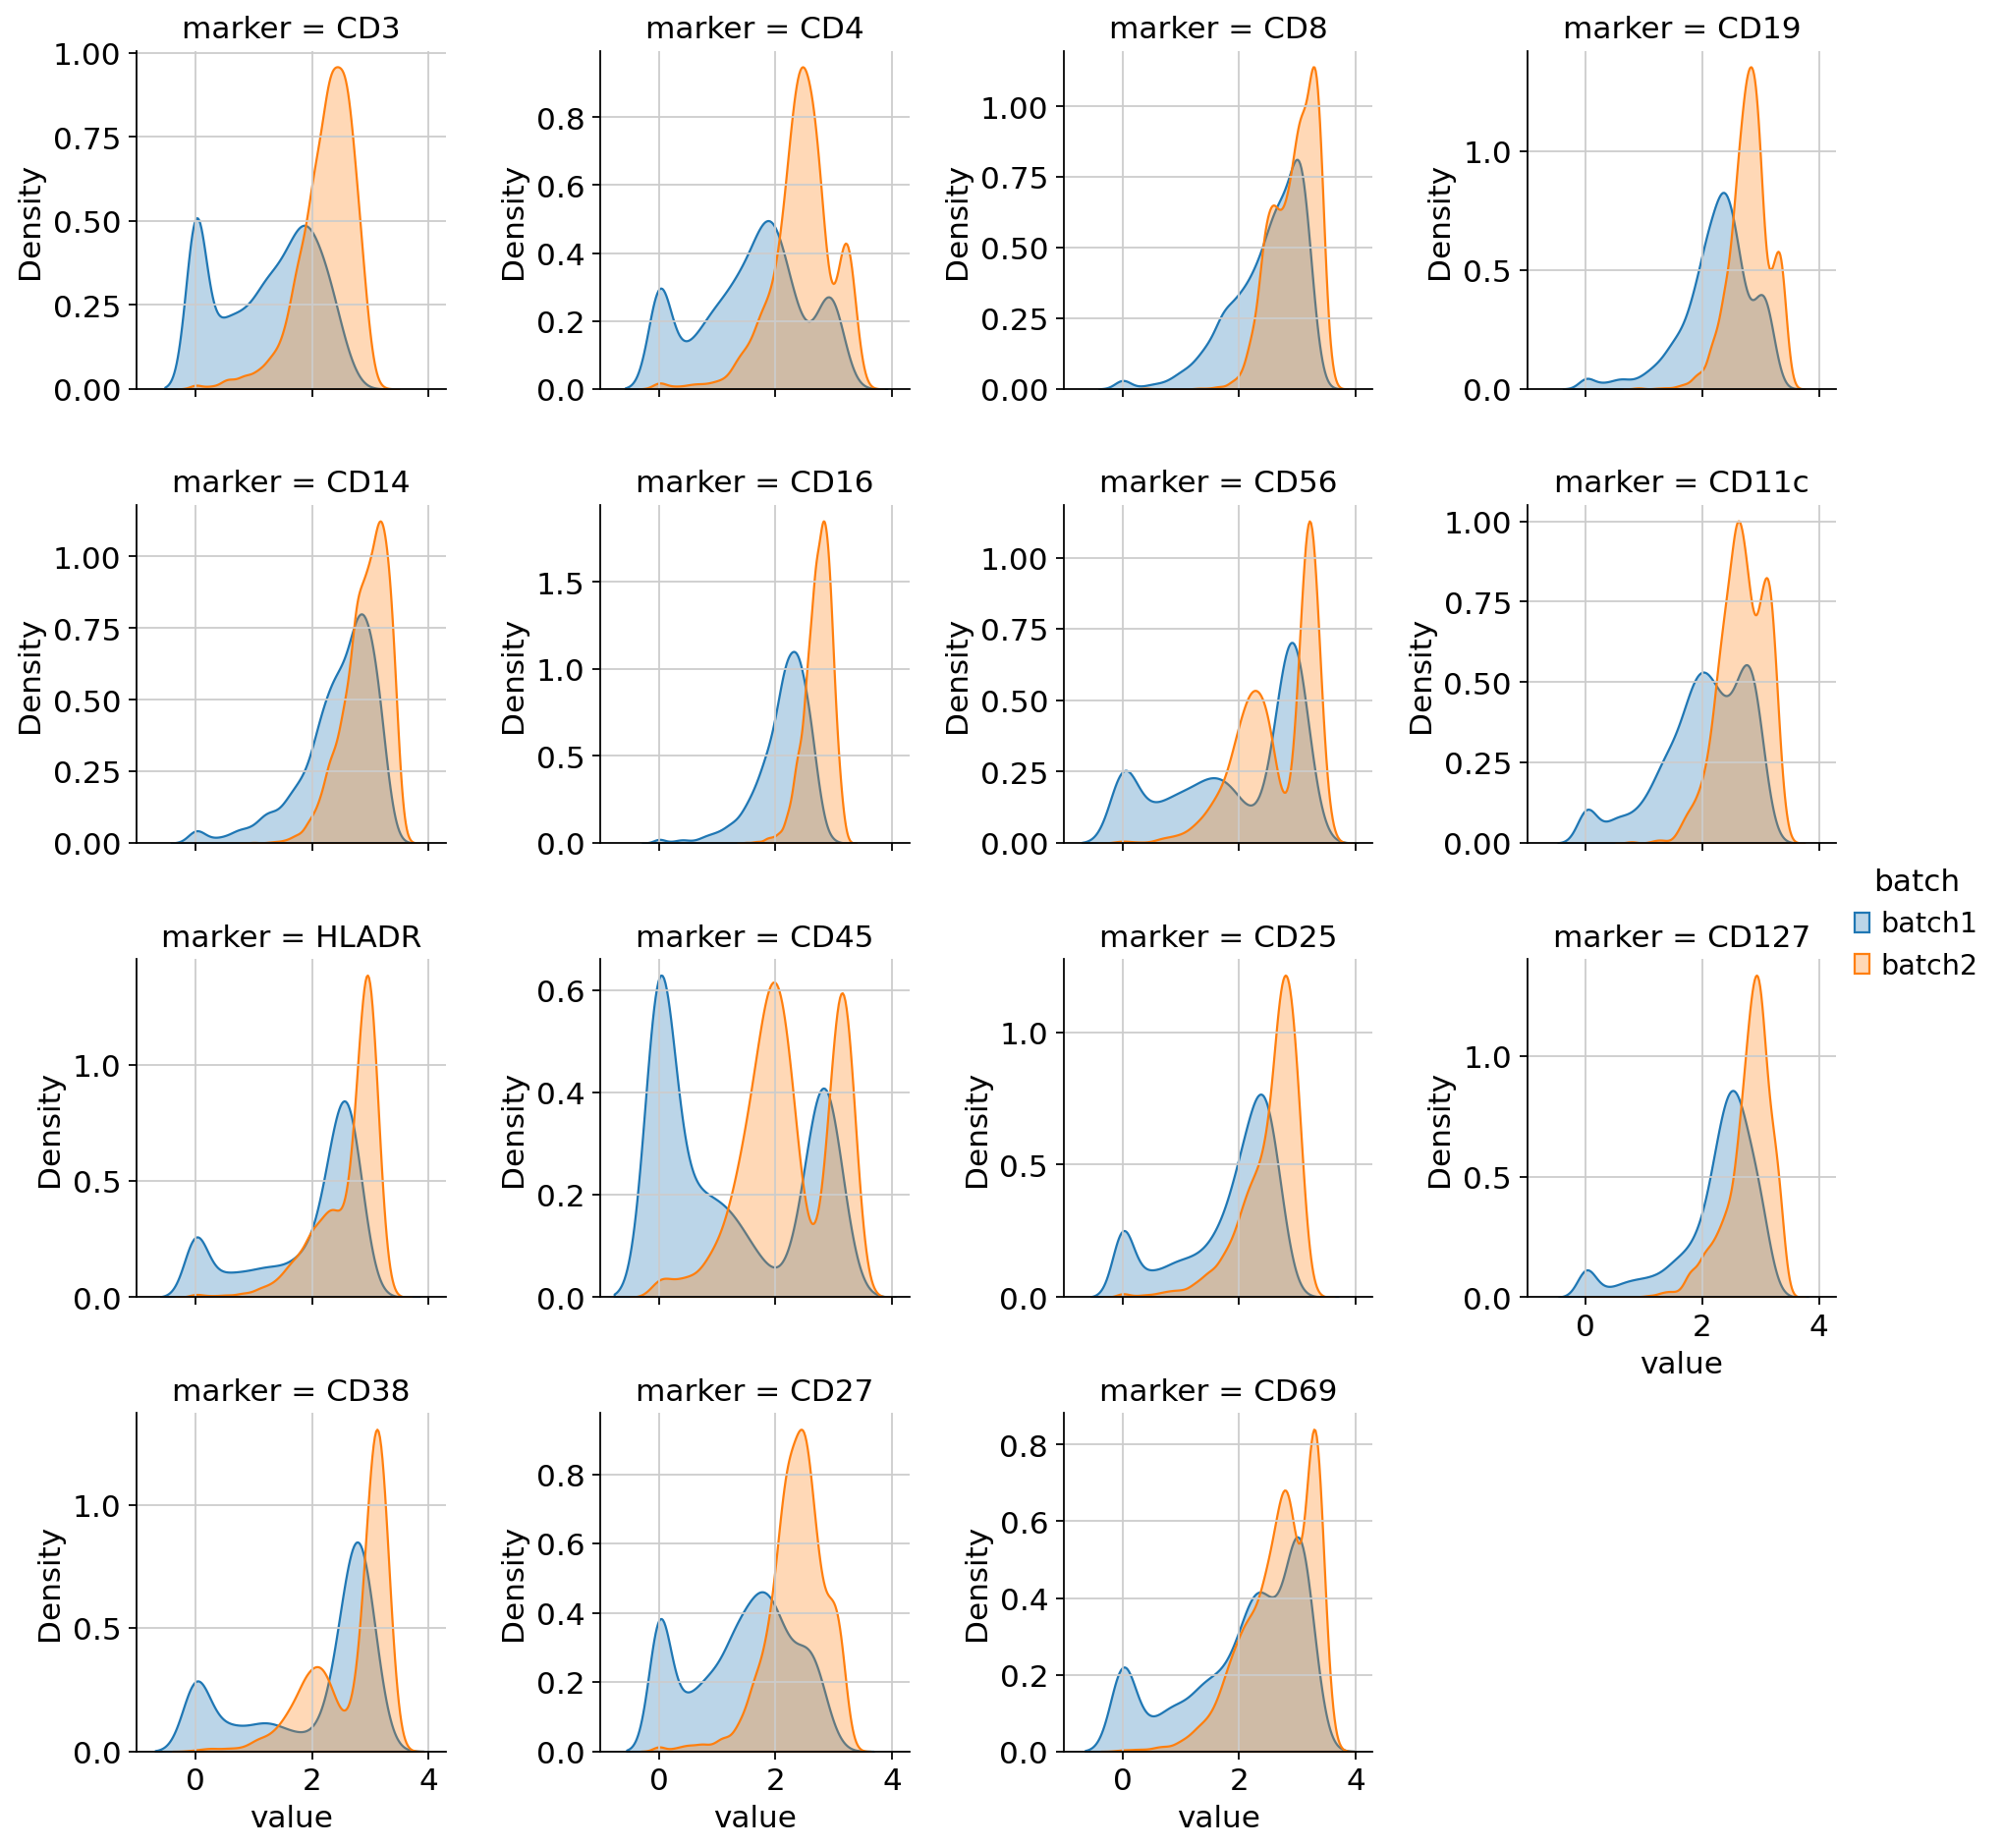

In [5]:
figs_express['density']

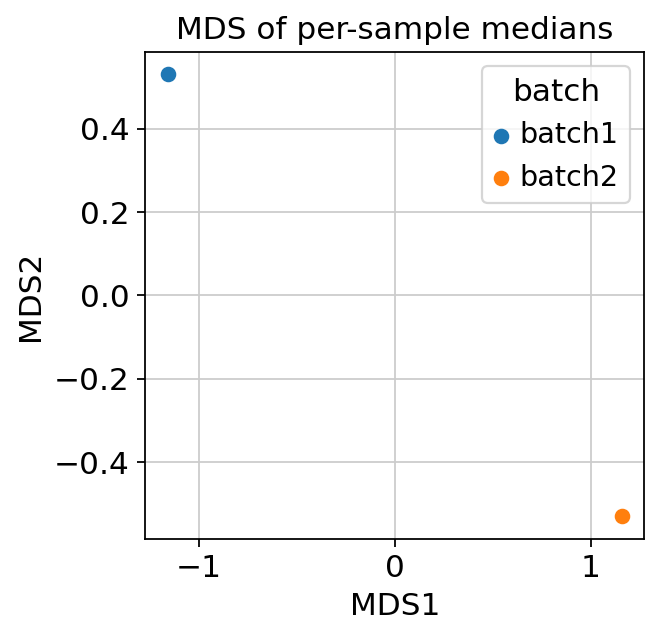

In [6]:
figs_express['mds']

## `detect_batch_effect` — the full diagnostic

`detect_batch_effect` runs the express diagnostics above and adds a
PCA-UMAP colored by batch plus a per-marker MAD bar chart. Use this
when you want a single report to decide whether correction is
warranted.

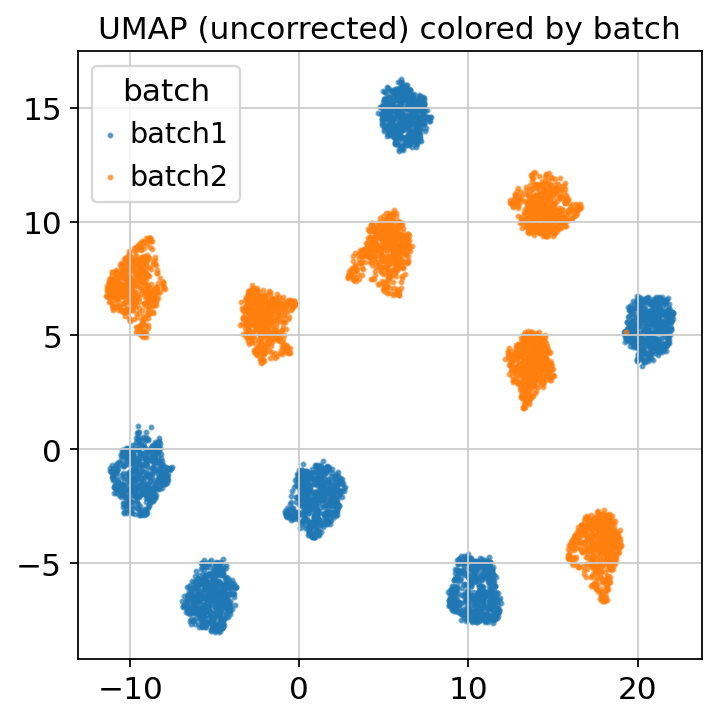

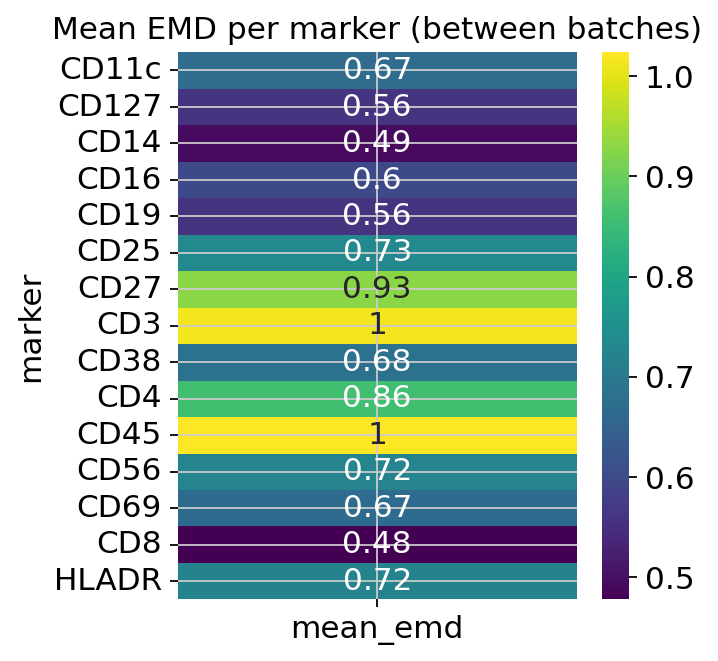

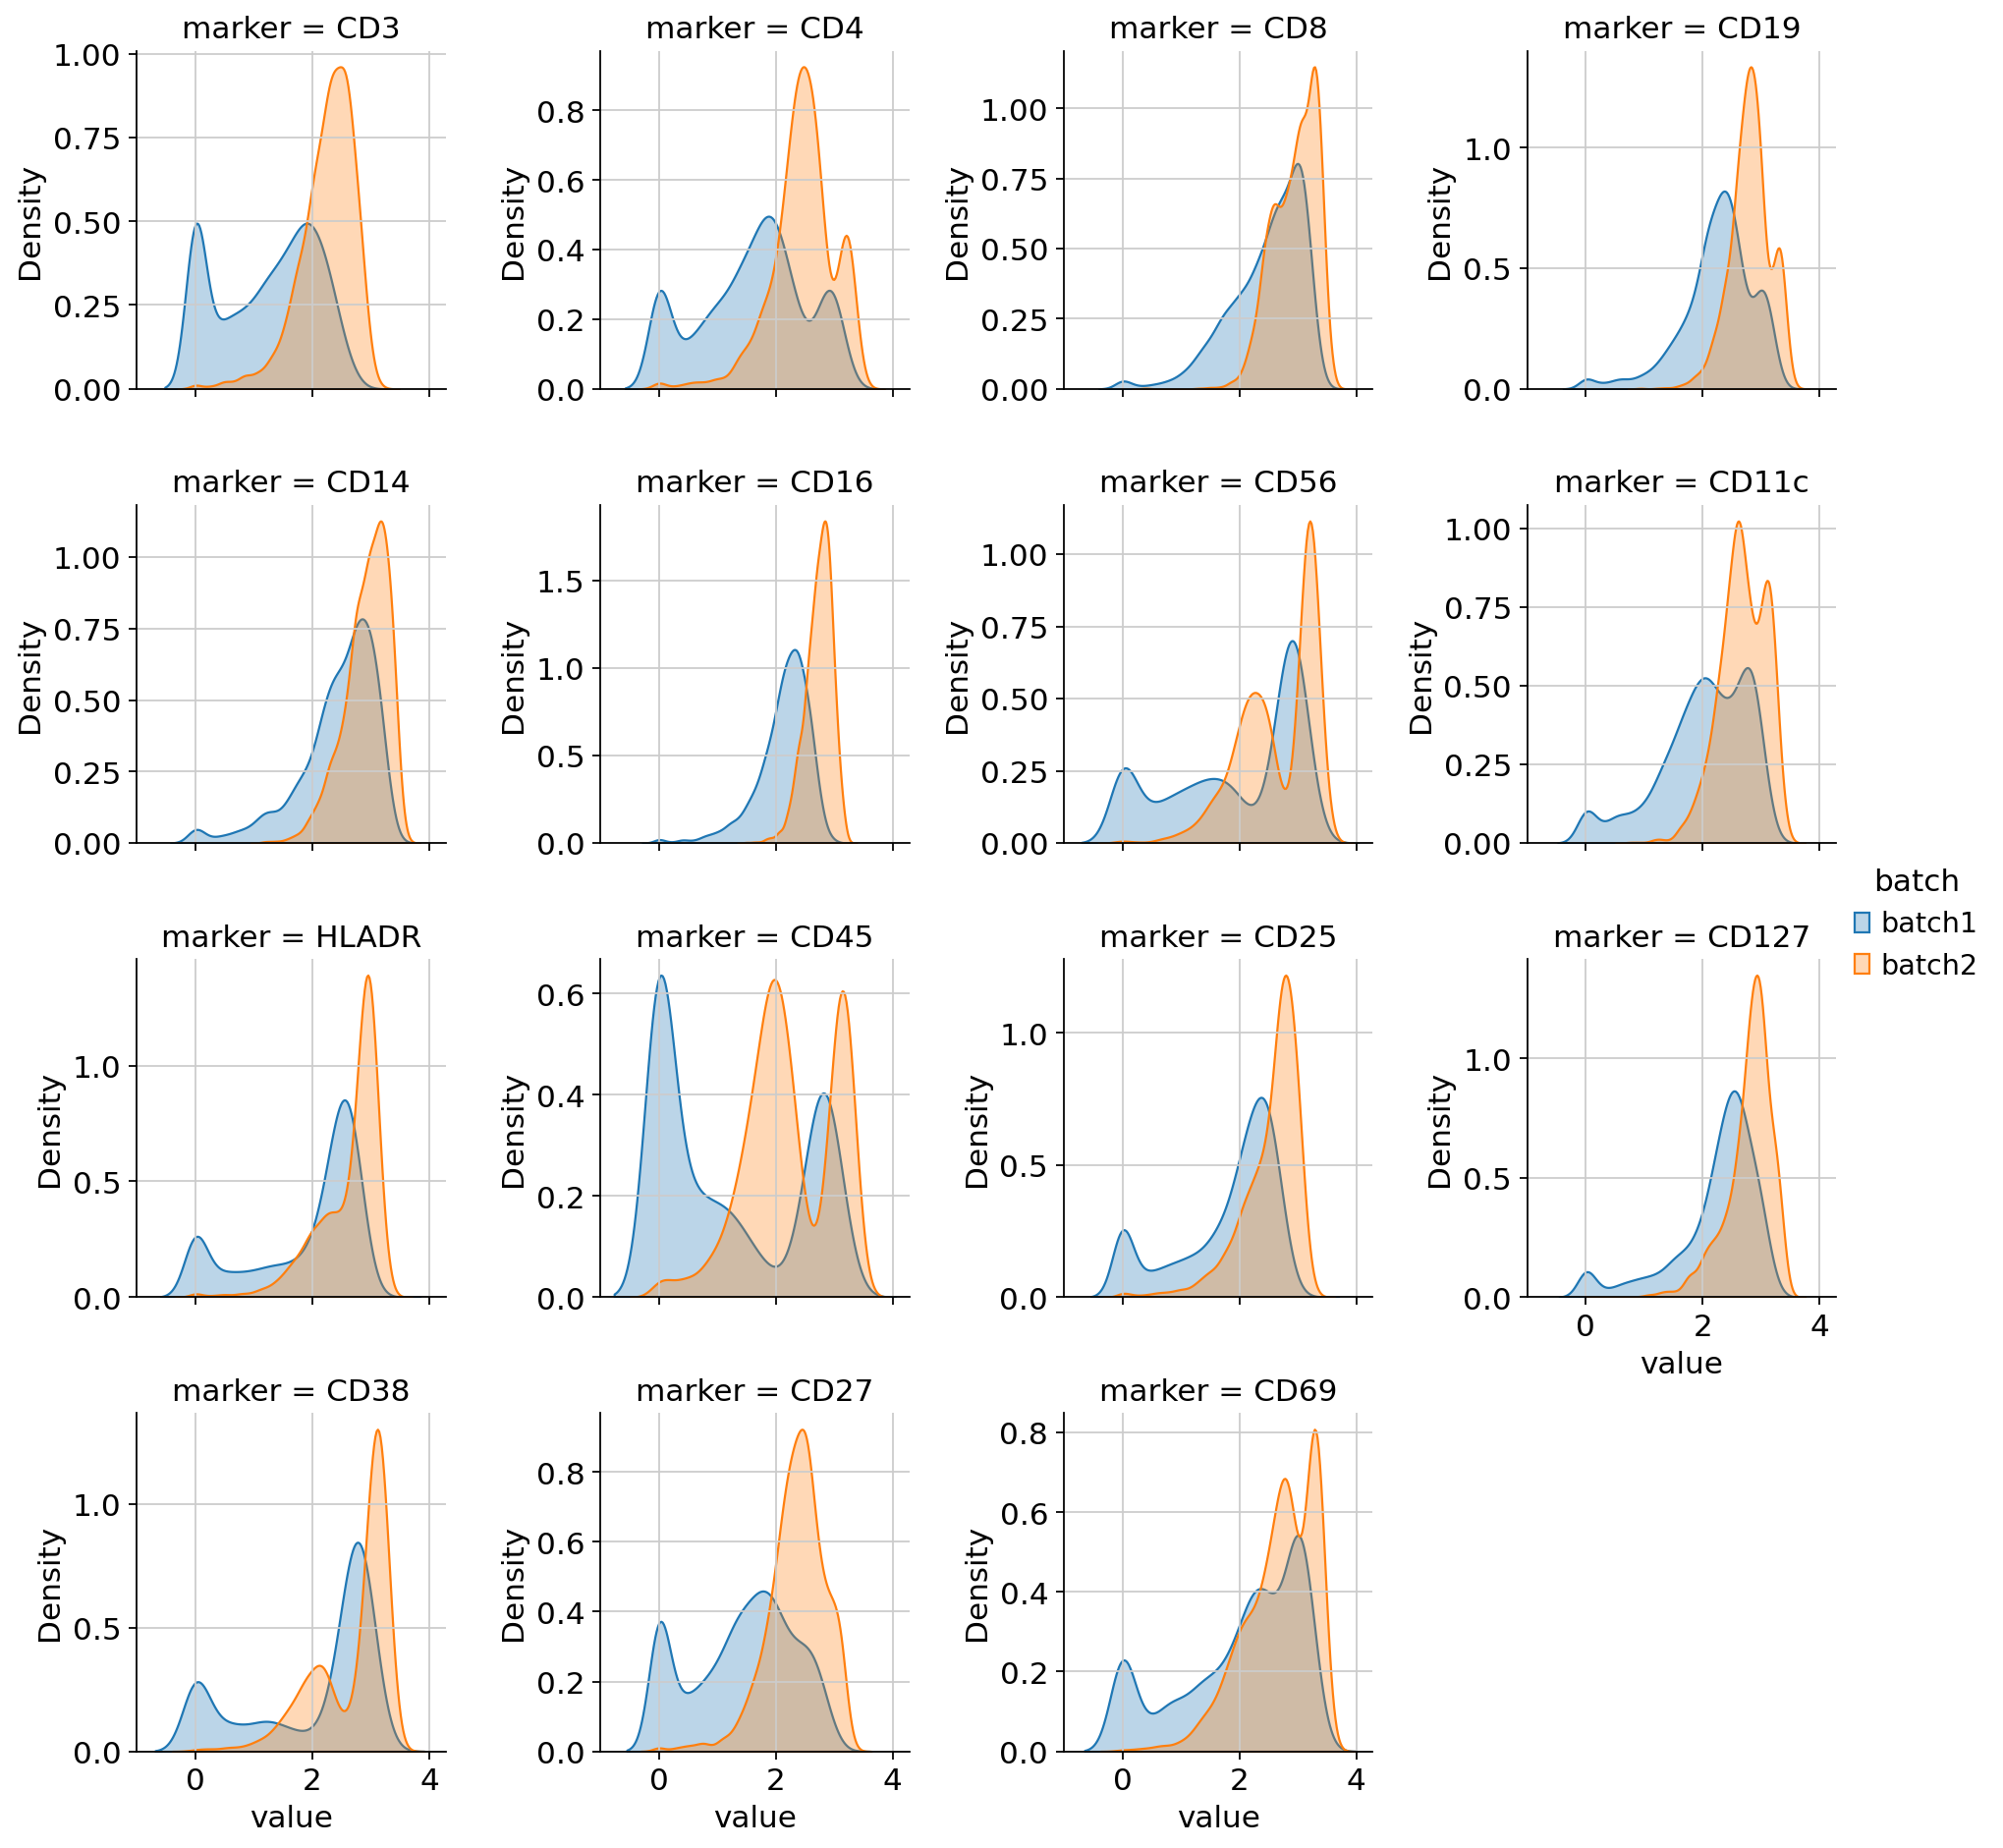

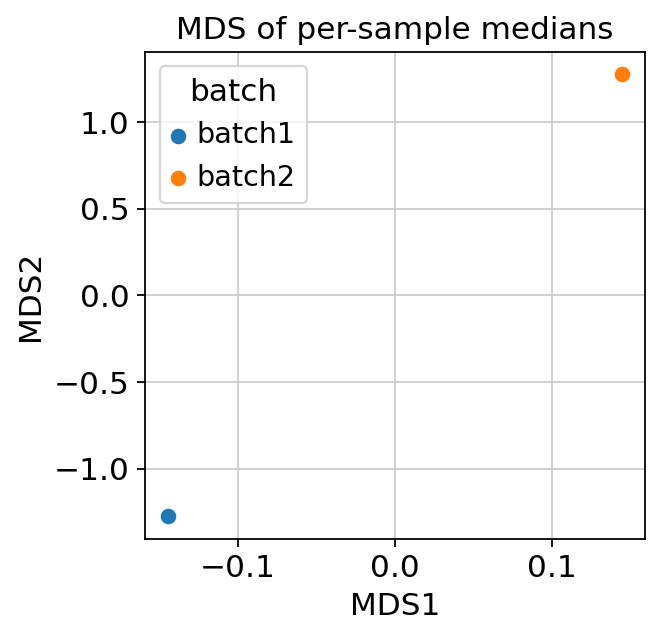

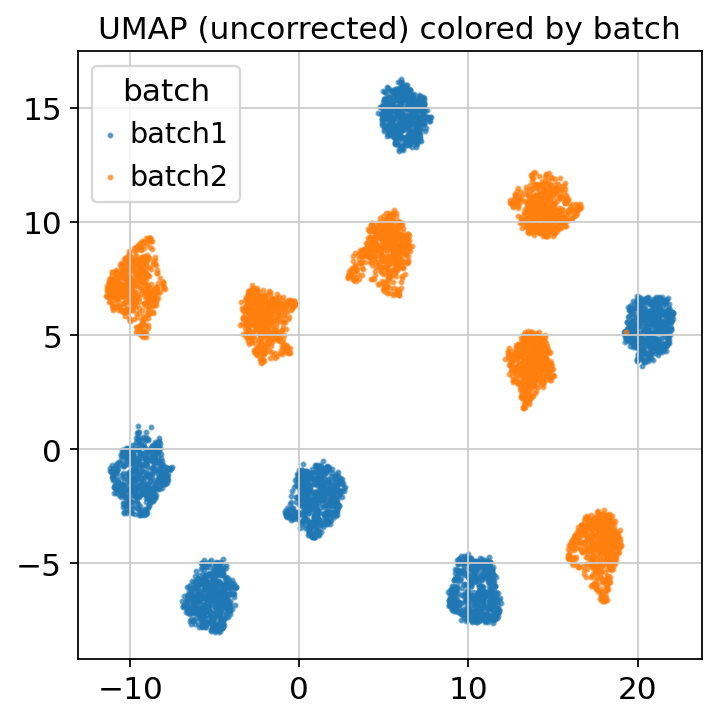

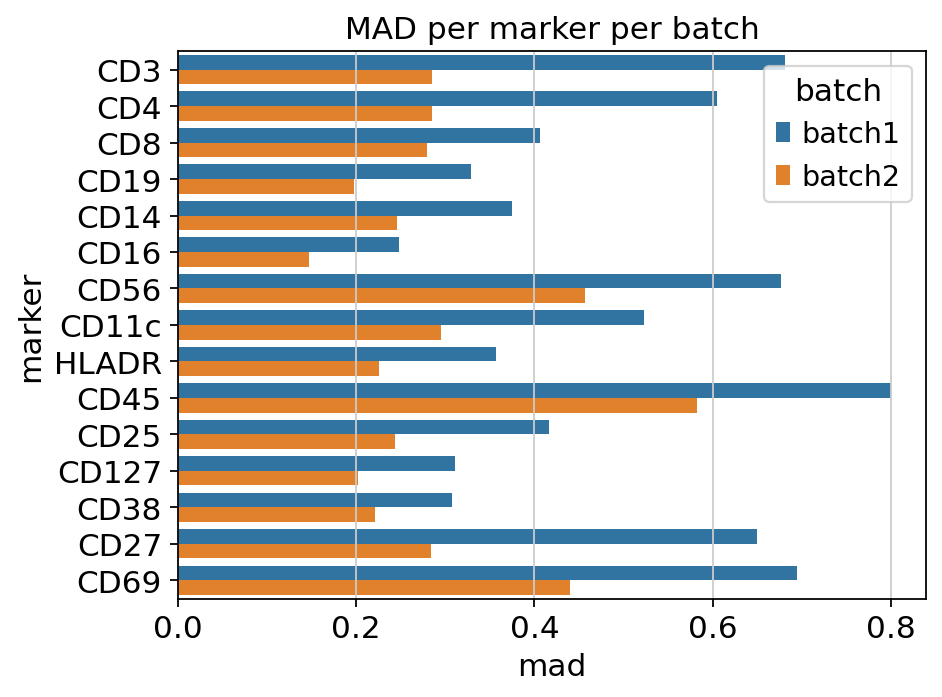

In [7]:
figs_full = pc.detect_batch_effect(
    adata,
    batch_key='batch',
    sample_key='sample',
    downsample=5000,
    out_dir=None,
    seed=434,
)
figs_full['umap']

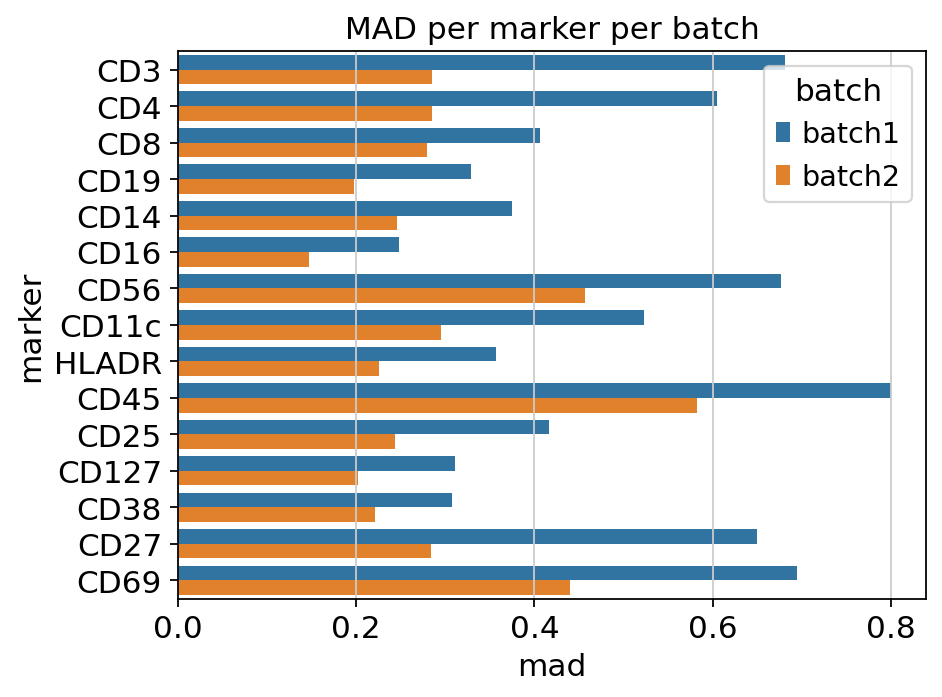

In [8]:
figs_full['mad']

## Interpreting the diagnostics

- **EMD heatmap** — large per-marker values indicate markers whose
  distributions differ most across batches. A marker with near-zero
  EMD is already well-aligned and does not need correction.
- **Density plots** — overlapping curves across batches are good; a
  bimodal split by batch indicates technical variation.
- **MDS of per-sample medians** — samples clustering by batch rather
  than by biology is a red flag.
- **UMAP colored by batch** — a clean batch-wise separation means a
  downstream embedding/clustering will be dominated by technical
  variation unless you correct.
- **Per-marker MAD** — large per-batch dispersion differences hint at
  instrument drift or sample-prep variability.

If these diagnostics flag a batch effect, proceed to the
{doc}`cycombine` tutorial to run the correction pipeline.